In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [7]:
# import
import numpy as np
import pandas as pd # 원핫인코딩
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pylab as plt # 학습과정 시각화

In [4]:
# 데이터 생성 및 전처리(라벨인코딩만 하고, 원핫인코딩x)

In [12]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                  test_size=0.1,
                                                  stratify=iris_y,
                                                  random_state=3)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((135, 4), (15, 4), (135,), (15,))

# 1. 기본적인 DNN(원핫인코딩x)

In [13]:
# model = Sequential()
# model.add(Input(4,))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))

model = Sequential([
    Input(4,),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
])
model.summary() # 250+1530+93 = 1873개 파라미터

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 50)                250       
                                                                 
 dense_7 (Dense)             (None, 30)                1530      
                                                                 
 dense_8 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [17]:
# 학습설정
model.compile(loss='sparse_categorical_crossentropy', # 라벨인코딩만 되어있는 경우
             optimizer='adam',
             metrics=['accuracy'])
# 학습
earlyStopping = EarlyStopping(patience=50) # monitor = 'val_loss' 기본값
hist = model.fit(train_X, train_y, epochs=1000,
                validation_split=0.2,
                callbacks=[earlyStopping])

Epoch 1/1000
4/4 [==============================] - 1s 67ms/step - loss: 1.3744 - accuracy: 0.3611 - val_loss: 1.2284 - val_accuracy: 0.6296
Epoch 2/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.0875 - accuracy: 0.6759 - val_loss: 0.9706 - val_accuracy: 0.6296
Epoch 3/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.8686 - accuracy: 0.6759 - val_loss: 0.7956 - val_accuracy: 0.6296
Epoch 4/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.7434 - accuracy: 0.6852 - val_loss: 0.7310 - val_accuracy: 0.8889
Epoch 5/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.7107 - accuracy: 0.7500 - val_loss: 0.7126 - val_accuracy: 0.6296
Epoch 6/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.6811 - accuracy: 0.6759 - val_loss: 0.6841 - val_accuracy: 0.6296
Epoch 7/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.6453 - accuracy: 0.6759 - val_loss: 0.6488 - val_accuracy: 0.6296
Epoch 8/1000


Epoch 59/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.2012 - accuracy: 0.9722 - val_loss: 0.2310 - val_accuracy: 1.0000
Epoch 60/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1984 - accuracy: 0.9815 - val_loss: 0.2267 - val_accuracy: 1.0000
Epoch 61/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1951 - accuracy: 0.9815 - val_loss: 0.2212 - val_accuracy: 1.0000
Epoch 62/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1885 - accuracy: 0.9815 - val_loss: 0.2183 - val_accuracy: 1.0000
Epoch 63/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1878 - accuracy: 0.9722 - val_loss: 0.2183 - val_accuracy: 0.9630
Epoch 64/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1832 - accuracy: 0.9722 - val_loss: 0.2078 - val_accuracy: 1.0000
Epoch 65/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1780 - accuracy: 0.9815 - val_loss: 0.2016 - val_accuracy: 1.0000
Epoch 

4/4 [==============================] - 0s 11ms/step - loss: 0.0817 - accuracy: 0.9815 - val_loss: 0.0787 - val_accuracy: 1.0000
Epoch 117/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0838 - accuracy: 0.9907 - val_loss: 0.0799 - val_accuracy: 1.0000
Epoch 118/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0846 - accuracy: 0.9907 - val_loss: 0.0767 - val_accuracy: 1.0000
Epoch 119/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0802 - accuracy: 0.9907 - val_loss: 0.0774 - val_accuracy: 1.0000
Epoch 120/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0797 - accuracy: 0.9722 - val_loss: 0.0770 - val_accuracy: 1.0000
Epoch 121/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0794 - accuracy: 0.9722 - val_loss: 0.0743 - val_accuracy: 1.0000
Epoch 122/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0794 - accuracy: 0.9815 - val_loss: 0.0728 - val_accuracy: 1.0000
Epoch 123/1000


4/4 [==============================] - 0s 12ms/step - loss: 0.0564 - accuracy: 0.9907 - val_loss: 0.0430 - val_accuracy: 1.0000
Epoch 174/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0593 - accuracy: 0.9907 - val_loss: 0.0424 - val_accuracy: 1.0000
Epoch 175/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0555 - accuracy: 0.9907 - val_loss: 0.0442 - val_accuracy: 1.0000
Epoch 176/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0563 - accuracy: 0.9722 - val_loss: 0.0458 - val_accuracy: 1.0000
Epoch 177/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0568 - accuracy: 0.9815 - val_loss: 0.0421 - val_accuracy: 1.0000
Epoch 178/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0565 - accuracy: 0.9907 - val_loss: 0.0411 - val_accuracy: 1.0000
Epoch 179/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0542 - accuracy: 0.9907 - val_loss: 0.0418 - val_accuracy: 1.0000
Epoch 180/1000

4/4 [==============================] - 0s 11ms/step - loss: 0.0445 - accuracy: 0.9907 - val_loss: 0.0302 - val_accuracy: 1.0000
Epoch 231/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0442 - accuracy: 0.9907 - val_loss: 0.0291 - val_accuracy: 1.0000
Epoch 232/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0438 - accuracy: 0.9907 - val_loss: 0.0285 - val_accuracy: 1.0000
Epoch 233/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0439 - accuracy: 0.9907 - val_loss: 0.0282 - val_accuracy: 1.0000
Epoch 234/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0471 - accuracy: 0.9907 - val_loss: 0.0284 - val_accuracy: 1.0000
Epoch 235/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0480 - accuracy: 0.9815 - val_loss: 0.0340 - val_accuracy: 1.0000
Epoch 236/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0461 - accuracy: 0.9907 - val_loss: 0.0293 - val_accuracy: 1.0000
Epoch 237/1000

4/4 [==============================] - 0s 10ms/step - loss: 0.0369 - accuracy: 0.9907 - val_loss: 0.0220 - val_accuracy: 1.0000
Epoch 288/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0399 - accuracy: 1.0000 - val_loss: 0.0220 - val_accuracy: 1.0000
Epoch 289/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0381 - accuracy: 1.0000 - val_loss: 0.0219 - val_accuracy: 1.0000
Epoch 290/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0381 - accuracy: 0.9815 - val_loss: 0.0254 - val_accuracy: 1.0000
Epoch 291/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0385 - accuracy: 0.9815 - val_loss: 0.0226 - val_accuracy: 1.0000
Epoch 292/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0361 - accuracy: 0.9907 - val_loss: 0.0208 - val_accuracy: 1.0000
Epoch 293/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0384 - accuracy: 1.0000 - val_loss: 0.0216 - val_accuracy: 1.0000
Epoch 294/1000


4/4 [==============================] - 0s 11ms/step - loss: 0.0324 - accuracy: 0.9907 - val_loss: 0.0183 - val_accuracy: 1.0000
Epoch 345/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0321 - accuracy: 0.9907 - val_loss: 0.0187 - val_accuracy: 1.0000
Epoch 346/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0322 - accuracy: 0.9907 - val_loss: 0.0176 - val_accuracy: 1.0000
Epoch 347/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0317 - accuracy: 0.9907 - val_loss: 0.0178 - val_accuracy: 1.0000
Epoch 348/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0314 - accuracy: 0.9907 - val_loss: 0.0173 - val_accuracy: 1.0000
Epoch 349/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0319 - accuracy: 0.9907 - val_loss: 0.0173 - val_accuracy: 1.0000
Epoch 350/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0327 - accuracy: 0.9907 - val_loss: 0.0164 - val_accuracy: 1.0000
Epoch 351/1000

4/4 [==============================] - 0s 7ms/step - loss: 0.0302 - accuracy: 0.9815 - val_loss: 0.0141 - val_accuracy: 1.0000
Epoch 402/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0271 - accuracy: 1.0000 - val_loss: 0.0125 - val_accuracy: 1.0000
Epoch 403/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0328 - accuracy: 0.9907 - val_loss: 0.0126 - val_accuracy: 1.0000
Epoch 404/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0289 - accuracy: 1.0000 - val_loss: 0.0147 - val_accuracy: 1.0000
Epoch 405/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0302 - accuracy: 0.9907 - val_loss: 0.0320 - val_accuracy: 0.9630
Epoch 406/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0388 - accuracy: 0.9815 - val_loss: 0.0264 - val_accuracy: 1.0000
Epoch 407/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0300 - accuracy: 0.9815 - val_loss: 0.0148 - val_accuracy: 1.0000
Epoch 408/1000


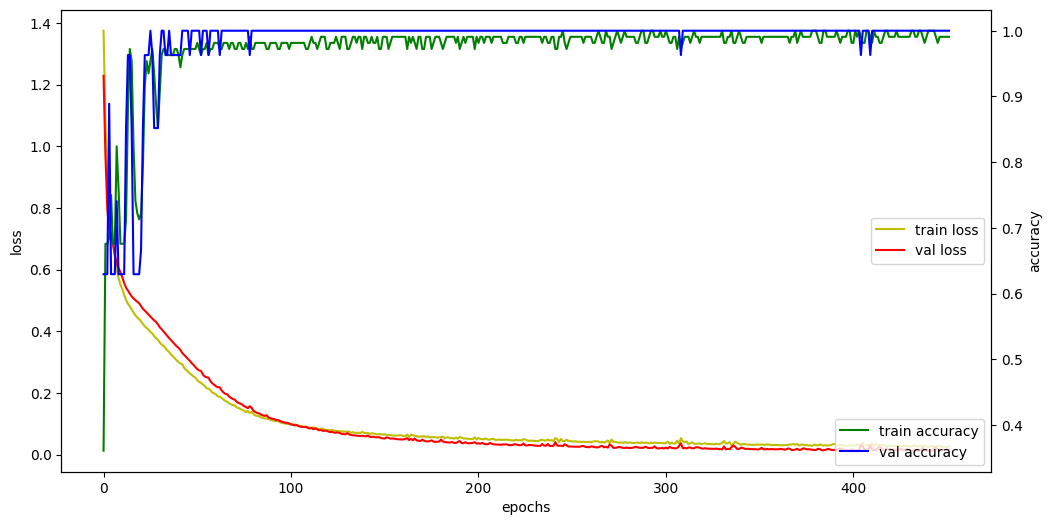

In [18]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# 2. sklearn 이용
- 원핫인코딩을 하지않고 라벨인코딩까지만 해야 작동. numpy배열

In [19]:
from sklearn.neural_network import MLPClassifier

In [20]:
# 머신러닝 3장 교재 43page
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                     activation='relu',
                     solver='adam',
                     alpha=0.001, #과적합 방지 강도
                     batch_size=40,
                     max_iter=1000, #epoch
                     early_stopping=True, #조기 종료 활성화(val_loss)
                     n_iter_no_change=50, # patience
                     warm_start=False, # True일 경우 이전학습에 이어서 학습
                     validation_fraction=0.1 # 검증셋 비율
                     )

In [21]:
mlp_model.fit(train_X, train_y)

MLPClassifier(alpha=0.001, batch_size=40, early_stopping=True,
              hidden_layer_sizes=(50, 30), max_iter=1000, n_iter_no_change=50)

In [33]:
# 모델 평가 : accuracy(test_X, test_y), recall, precision(test_y, y_hat)
from sklearn.metrics import recall_score, precision_score
accuracy = mlp_model.score(test_X, test_y)
y_hat = mlp_model.predict(test_X)
recall = recall_score(test_y, y_hat, average='weighted')
precision = precision_score(test_y, y_hat, average='weighted')
print(test_y, y_hat)
print('정확도 : {:.2f}, 재현율 : {:.2f}, 정밀도 : {:.2f}'.format(accuracy, recall, precision))
print('교차표\n', pd.crosstab(test_y, y_hat,
                          rownames=['실제'],
                          colnames=['예측']))

[0 2 2 0 1 0 2 0 1 1 2 0 1 2 1] [0 2 2 0 1 0 2 0 2 2 2 0 1 2 2]
정확도 : 0.80, 재현율 : 0.80, 정밀도 : 0.88
교차표
 예측  0  1  2
실제         
0   5  0  0
1   0  2  3
2   0  0  5


# 3. 클래스 이용

In [36]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu'):
#         model = Sequential()
#         model.add(Input(input_dim,))
#         model.add(Dense(50, activation=activation))
#         model.add(Dense(30, activation=activation))
#         model.add(Dense(3, activation='softmax'))
        model = Sequential([
            Input(input_dim,),
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax'),
        ])
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])
        return model

In [39]:
%%time
# 모델
model = DNNClassifier.build(input
                            _dim=4, activation='relu')
model.summary()
# 모델 학습
hist = model.fit(train_X, train_y,
                epochs=500,
                validation_split=0.2,
                verbose=0)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 50)                250       
                                                                 
 dense_19 (Dense)            (None, 30)                1530      
                                                                 
 dense_20 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
CPU times: total: 27.7 s
Wall time: 21.8 s


In [41]:
loss, accuracy = model.evaluate(test_X, test_y)
loss, accuracy

1/1 [==============================] - 0s 26ms/step - loss: 0.2549 - accuracy: 0.9333


(0.2548695206642151, 0.9333333373069763)

# 4. 함수형 API 이용하기
- 병렬처리: 속도 높이려고
- 레지듀얼블록(Residual block): 모델의 성능을 높이려고(자연어, 이미지 처리)

In [43]:
# import
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Model # 모델 생성(입력층과 출력층을 이용)
from tensorflow.keras.layers import Dense, Input, add # add: 레지듀얼블럭
from tensorflow.keras.layers import concatenate # 병렬 처리시
import matplotlib.pylab as plt # 학습과정 시각화

In [44]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 되어있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                  test_size=0.1,
                                                  stratify=iris_y,
                                                  random_state=3)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((135, 4), (15, 4), (135,), (15,))

In [49]:
# 기존의 모델 스타일 4 -> 50 -> 30 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=30, activation='relu')(dense1)
dense3 = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=dense3)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=30,
         validation_split=0.2)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_26 (Dense)            (None, 50)                250       
                                                                 
 dense_27 (Dense)            (None, 30)                1530      
                                                                 
 dense_28 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
4/4 [==============================] - 1s 59ms/step - loss: 1.6185 - accuracy: 0.3241 - val_loss: 1.4093 - val_accuracy: 0.3704
Epoch 2/30
4/4 [==============================] - 

In [53]:
# 병렬처리
# 4 -> 160(50, 80, 30로 병렬처리) -> 32 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x = concatenate([dense1, dense2, dense3])
# x = Dense(units=160, activation='relu')(inpiut_) 의 병렬처리
dense4 = Dense(units=32, activation='relu')(x)
output = Dense(units=3, activation='softmax')(dense4)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_15 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_44 (Dense)               (None, 50)           250         ['input_15[0][0]']               
                                                                                                  
 dense_45 (Dense)               (None, 80)           400         ['input_15[0][0]']               
                                                                                                  
 dense_46 (Dense)               (None, 30)           150         ['input_15[0][0]']               
                                                                                            

In [55]:
%%time
# 레지듀얼블록(residual Block): 딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을 때
# 4 -> 50 -> 50 -> (residual) -> 3
input_ = Input(shape=(4,))
dense1 = Dense(50, activation='relu')(input_)
dense2 = Dense(50, activation='relu')(dense1)
dense3 = add([dense1, dense2])
output = Dense(3, activation='softmax')(dense3)
model = Model(inputs=input_, outputs=output)
model.summary()
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=500,
         validation_split=0.2, verbose=0)

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_17 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_52 (Dense)               (None, 50)           250         ['input_17[0][0]']               
                                                                                                  
 dense_53 (Dense)               (None, 50)           2550        ['dense_52[0][0]']               
                                                                                                  
 add_1 (Add)                    (None, 50)           0           ['dense_52[0][0]',               
                                                                  'dense_53[0][0]']         

In [56]:
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 26ms/step - loss: 0.3382 - accuracy: 0.9333


[0.33820822834968567, 0.9333333373069763]